Raw dataset moved to data/raw/
Dataset shape: (14041, 103)
   RaceEth  HowOldAreYou  WhatIsYourSex  InWhatGradeAreYou  \
0      7.0           4.0            2.0                2.0   
1      5.0           7.0            2.0                2.0   
2      NaN           NaN            2.0                NaN   
3      7.0           1.0            1.0                1.0   
4      7.0           1.0            1.0                5.0   

   AreYouHispanicOrLatino WhatIsYourRace  HowTallAreYouWithoutShoesInMeters  \
0                     1.0              C                                NaN   
1                     2.0              E                               1.70   
2                     NaN            NaN                                NaN   
3                     1.0              A                               1.63   
4                     1.0              B                                NaN   

   HowMuchDoYouWeighWithoutShoesInKG  BicyleHelmetUse  SeatBeltUse  ...  \
0                 

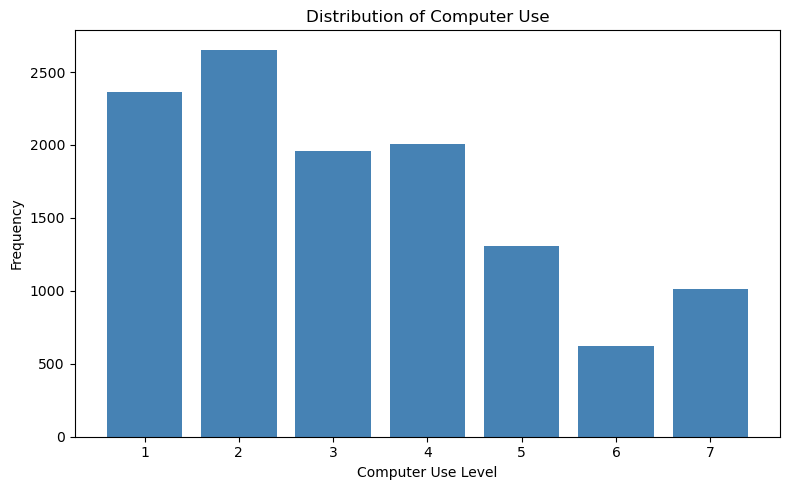

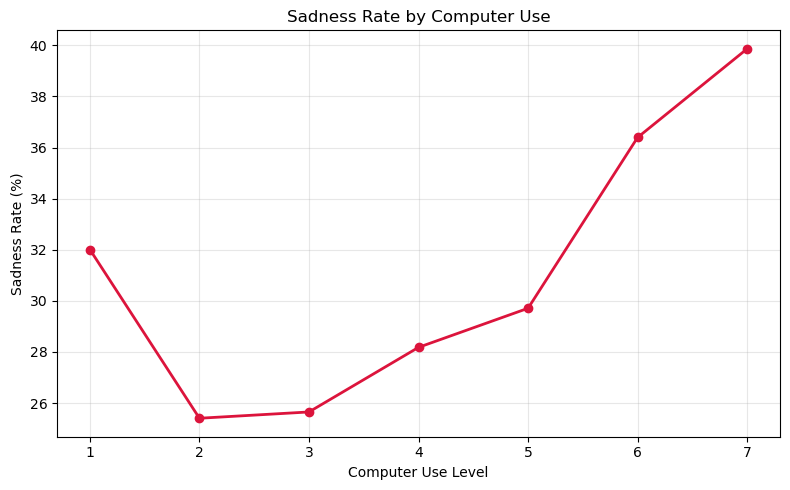

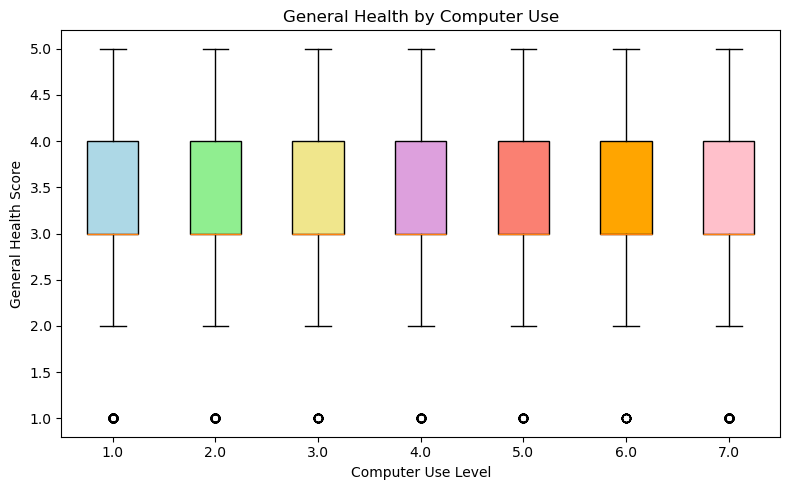

Optimization terminated successfully.
         Current function value: 0.590201
         Iterations 5


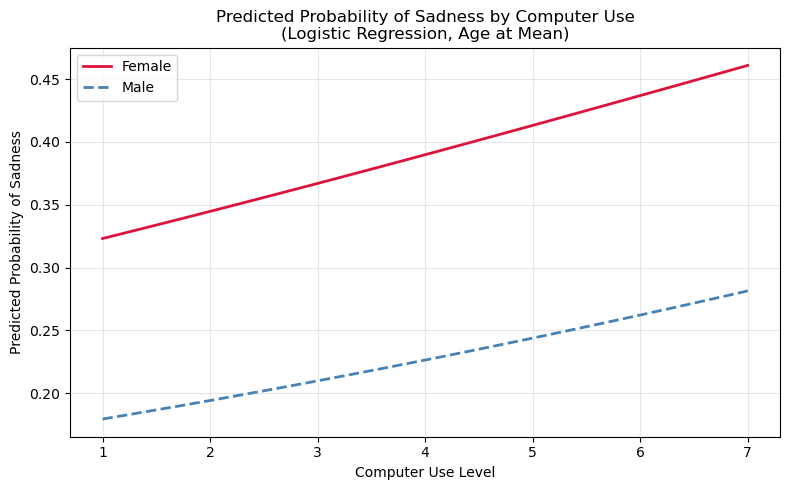

All figures saved.
                            OLS Regression Results                            
Dep. Variable:             sad_binary   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     32.13
Date:                Fri, 12 Jun 2026   Prob (F-statistic):           1.48e-08
Time:                        16:17:15   Log-Likelihood:                -7540.1
No. Observations:               11923   AIC:                         1.508e+04
Df Residuals:                   11921   BIC:                         1.510e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.2530      

In [2]:
import os
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ─────────────────────────────────────────────
# 1. SETUP: Create folder structure
# ─────────────────────────────────────────────

FOLDERS = [
    "data/raw",
    "data/processed",
    "notebooks",
    "outputs/figures",
    "outputs/tables",
    "outputs/summary",
    "references",
]

for folder in FOLDERS:
    os.makedirs(folder, exist_ok=True)


# ─────────────────────────────────────────────
# 2. DATA LOADING
# ─────────────────────────────────────────────

RAW_FILE = "data/raw/YRBS_2007.csv"
ORIGINAL_FILE = "YRBS_2007.csv"

if os.path.exists(ORIGINAL_FILE) and not os.path.exists(RAW_FILE):
    shutil.move(ORIGINAL_FILE, RAW_FILE)
    print("Raw dataset moved to data/raw/")
elif os.path.exists(RAW_FILE):
    print("Raw dataset already in place.")
else:
    raise FileNotFoundError("YRBS_2007.csv not found in current directory or data/raw/.")

df = pd.read_csv(RAW_FILE)
print(f"Dataset shape: {df.shape}")
print(df.head())


# ─────────────────────────────────────────────
# 3. DATA CLEANING & RECODING
# ─────────────────────────────────────────────

SELECTED_COLUMNS = ["ComputerUse", "SadOrHopeless", "HealthInGeneral", "WhatIsYourSex", "HowOldAreYou"]
RENAME_MAP = {
    "ComputerUse":    "computer_use",
    "SadOrHopeless":  "sad_or_hopeless",
    "HealthInGeneral": "health",
    "WhatIsYourSex":  "sex",
    "HowOldAreYou":   "age",
}

data = (
    df[SELECTED_COLUMNS]
    .copy()
    .dropna()
    .rename(columns=RENAME_MAP)
)

# Recode variables
data["sad_binary"]   = data["sad_or_hopeless"].map({1: 1, 2: 0})   # 1=sad, 0=not sad
data["female"]       = data["sex"].map({1: 1, 2: 0})               # 1=female, 0=male
data["health_score"] = 6 - data["health"]                          # Reverse: higher = better health

# Final analysis dataset
ANALYSIS_COLS = ["computer_use", "sad_binary", "health_score", "female", "age"]
analysis_data = data[ANALYSIS_COLS].dropna()

print(f"\nAnalysis dataset shape: {analysis_data.shape}")
print(analysis_data.head())

# Save cleaned data
CLEANED_PATH = "data/processed/cleaned_YRBS_screen_time_mental_health.csv"
analysis_data.to_csv(CLEANED_PATH, index=False)
print(f"Cleaned data saved to {CLEANED_PATH}")


# ─────────────────────────────────────────────
# 4. DESCRIPTIVE STATISTICS
# ─────────────────────────────────────────────

descriptive_stats = analysis_data.describe()
print("\nDescriptive Statistics:")
print(descriptive_stats)
descriptive_stats.to_csv("outputs/tables/descriptive_statistics.csv")

# Table 1: Sadness rate by computer use level
sadness_table = (
    analysis_data
    .groupby("computer_use")["sad_binary"]
    .agg(count="count", mean="mean")
    .reset_index()
    .assign(sadness_rate=lambda x: x["mean"] * 100)
)
print("\nSadness Rate by Computer Use:")
print(sadness_table)
sadness_table.to_csv("outputs/tables/sadness_rate_by_computer_use.csv", index=False)

# Table 2: General health by computer use level
health_table = (
    analysis_data
    .groupby("computer_use")["health_score"]
    .agg(count="count", mean="mean", std="std")
    .reset_index()
)
print("\nGeneral Health by Computer Use:")
print(health_table)
health_table.to_csv("outputs/tables/health_by_computer_use.csv", index=False)


# ─────────────────────────────────────────────
# 5. FIGURES
# ─────────────────────────────────────────────

# Figure 1: Distribution of Computer Use
computer_counts = analysis_data["computer_use"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(computer_counts.index, computer_counts.values, color="steelblue")
plt.title("Distribution of Computer Use")
plt.xlabel("Computer Use Level")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("outputs/figures/figure1_computer_use_distribution.png", dpi=300)
plt.show()

# Figure 2: Sadness Rate by Computer Use
plt.figure(figsize=(8, 5))
plt.plot(
    sadness_table["computer_use"],
    sadness_table["sadness_rate"],
    marker="o", linewidth=2, color="crimson",
)
plt.title("Sadness Rate by Computer Use")
plt.xlabel("Computer Use Level")
plt.ylabel("Sadness Rate (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/figures/figure2_sadness_rate_by_computer_use.png", dpi=300)
plt.show()

# Figure 3: General Health by Computer Use (box plot)
computer_levels = sorted(analysis_data["computer_use"].unique())
health_groups = [
    analysis_data.loc[analysis_data["computer_use"] == level, "health_score"]
    for level in computer_levels
]

BOX_COLORS = ["lightblue", "lightgreen", "khaki", "plum", "salmon", "orange", "pink"]

plt.figure(figsize=(8, 5))
box = plt.boxplot(health_groups, patch_artist=True)
for patch, color in zip(box["boxes"], BOX_COLORS):
    patch.set_facecolor(color)
plt.title("General Health by Computer Use")
plt.xlabel("Computer Use Level")
plt.ylabel("General Health Score")
plt.xticks(range(1, len(computer_levels) + 1), computer_levels)
plt.tight_layout()
plt.savefig("outputs/figures/figure3_general_health_by_computer_use.png", dpi=300)
plt.show()

# ── NEW ── Figure 4: Predicted Sadness Probability (Logistic Regression)
logit_model = smf.logit("sad_binary ~ computer_use + female + age", data=analysis_data).fit()

cu_range = np.linspace(analysis_data["computer_use"].min(), analysis_data["computer_use"].max(), 100)
pred_df_female = pd.DataFrame({"computer_use": cu_range, "female": 1, "age": analysis_data["age"].mean()})
pred_df_male   = pd.DataFrame({"computer_use": cu_range, "female": 0, "age": analysis_data["age"].mean()})

plt.figure(figsize=(8, 5))
plt.plot(cu_range, logit_model.predict(pred_df_female), color="crimson", linewidth=2, label="Female")
plt.plot(cu_range, logit_model.predict(pred_df_male),   color="steelblue", linewidth=2, label="Male", linestyle="--")
plt.title("Predicted Probability of Sadness by Computer Use\n(Logistic Regression, Age at Mean)")
plt.xlabel("Computer Use Level")
plt.ylabel("Predicted Probability of Sadness")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/figures/figure4_predicted_sadness_probability.png", dpi=300)
plt.show()

print("All figures saved.")


# ─────────────────────────────────────────────
# 6. REGRESSION MODELS
# ─────────────────────────────────────────────

# Model 1: OLS — Computer Use → Sadness (bivariate)
X1 = sm.add_constant(analysis_data[["computer_use"]])
model1 = sm.OLS(analysis_data["sad_binary"], X1).fit()
print(model1.summary())

with open("outputs/tables/model1_computer_use_sadness.txt", "w") as f:
    f.write(model1.summary().as_text())

# Model 2: OLS — Computer Use + Controls → Sadness
X2 = sm.add_constant(analysis_data[["computer_use", "female", "age"]])
model2 = sm.OLS(analysis_data["sad_binary"], X2).fit()
print(model2.summary())

with open("outputs/tables/model2_computer_use_controls_sadness.txt", "w") as f:
    f.write(model2.summary().as_text())

# ── NEW ── Model 3: Logistic Regression — Computer Use + Controls → Sadness
print(logit_model.summary())

with open("outputs/tables/model3_logistic_sadness.txt", "w") as f:
    f.write(logit_model.summary().as_text())

# Regression Summary Table (all three models)
regression_summary = pd.DataFrame({
    "Model": [
        "OLS: Computer Use → Sadness",
        "OLS: Computer Use + Controls → Sadness",
        "Logistic: Computer Use + Controls → Sadness",
    ],
    "Coefficient": [
        model1.params["computer_use"],
        model2.params["computer_use"],
        logit_model.params["computer_use"],
    ],
    "P_value": [
        model1.pvalues["computer_use"],
        model2.pvalues["computer_use"],
        logit_model.pvalues["computer_use"],
    ],
    "R_squared / Pseudo_R2": [
        model1.rsquared,
        model2.rsquared,
        logit_model.prsquared,
    ],
})
print("\nRegression Summary:")
print(regression_summary)
regression_summary.to_csv("outputs/tables/regression_summary_table.csv", index=False)


# ─────────────────────────────────────────────
# 7. INTERPRETATION
# ─────────────────────────────────────────────

coef   = model2.params["computer_use"]
pvalue = model2.pvalues["computer_use"]

print("\n========== Interpretation (OLS Model 2) ==========")
print(f"Coefficient : {coef:.4f}")
print(f"P-value     : {pvalue:.4f}")

if pvalue < 0.05:
    print("Computer use is significantly associated with sadness and hopelessness.")
else:
    print("Computer use is NOT significantly associated with sadness and hopelessness.")

direction = "higher" if coef > 0 else "lower"
print(f"Higher computer use is associated with a {direction} sadness level.")
print("Note: Association does not imply causation.")


# ─────────────────────────────────────────────
# 8. FINAL SUMMARY
# ─────────────────────────────────────────────

print("\n========== Project Completed ==========")
print(f"Raw data      : {RAW_FILE}")
print(f"Cleaned data  : {CLEANED_PATH}")
print("Figures       : outputs/figures/")
print("Tables        : outputs/tables/")
print("Summary       : outputs/summary/")
print("\nProject completed successfully.")
